In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from validation import cargar_json

# Decisión del agente supervisor

Este notebook analiza qué agente se utiliza para responder diferentes tipos de preguntas: Ejemplo, Práctica o Teoría, y evalúa la precisión de cada uno.

=== Análisis General ===
Total de preguntas: 20
Preguntas respondidas adecuadamente: 16
Porcentaje de acierto: 80.00%


=== Análisis por Tipo de Agente Esperado ===
                 total_preguntas  respuestas_correctas  porcentaje_correcto
agente_esperado                                                            
Ejemplo                        7                     6            85.714286
Práctica                       6                     4            66.666667
Teoría                         7                     6            85.714286




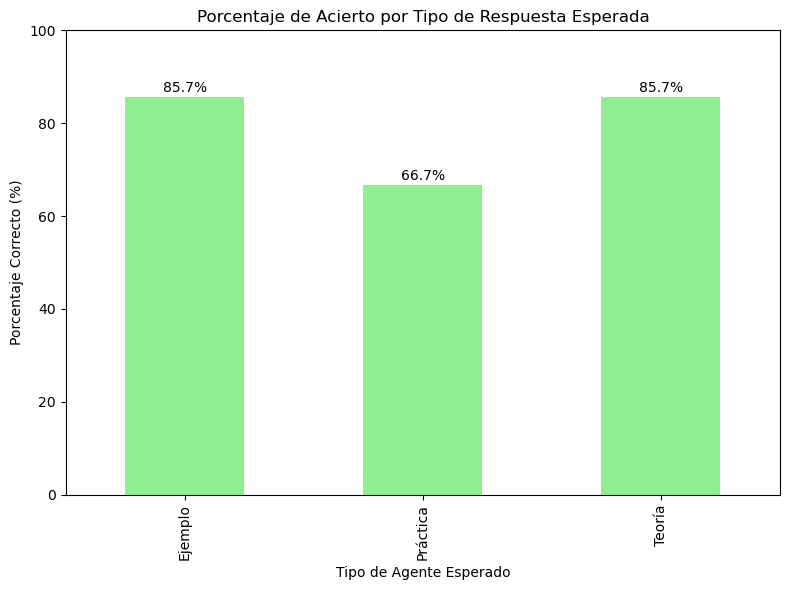

In [38]:
# Datos proporcionados
data = cargar_json("results.json")

# Crear DataFrame
df = pd.DataFrame(data)

# Agregar columna para indicar si la respuesta fue adecuada
df['respuesta_adecuada'] = df['agente_esperado'] == df['resultado']

# Análisis general
total_preguntas = len(df)
preguntas_correctas = df['respuesta_adecuada'].sum()
porcentaje_correcto = (preguntas_correctas / total_preguntas) * 100

# Análisis por tipo de agente esperado
analisis_por_tipo = df.groupby('agente_esperado').agg(
    total_preguntas=('pregunta', 'count'),
    respuestas_correctas=('respuesta_adecuada', 'sum')
)
analisis_por_tipo['porcentaje_correcto'] = (analisis_por_tipo['respuestas_correctas'] / analisis_por_tipo['total_preguntas']) * 100

# Mostrar resultados
print("=== Análisis General ===")
print(f"Total de preguntas: {total_preguntas}")
print(f"Preguntas respondidas adecuadamente: {preguntas_correctas}")
print(f"Porcentaje de acierto: {porcentaje_correcto:.2f}%")
print("\n")

print("=== Análisis por Tipo de Agente Esperado ===")
print(analisis_por_tipo)
print("\n")

# Visualización - Solo un gráfico
plt.figure(figsize=(8, 6))

# Gráfico: Porcentaje de acierto por tipo
analisis_por_tipo['porcentaje_correcto'].plot(kind='bar', color='lightgreen')
plt.title('Porcentaje de Acierto por Tipo de Respuesta Esperada')
plt.xlabel('Tipo de Agente Esperado')
plt.ylabel('Porcentaje Correcto (%)')
plt.ylim(0, 100)

# Agregar etiquetas con los valores
for i, v in enumerate(analisis_por_tipo['porcentaje_correcto']):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'Matriz de Confusión')

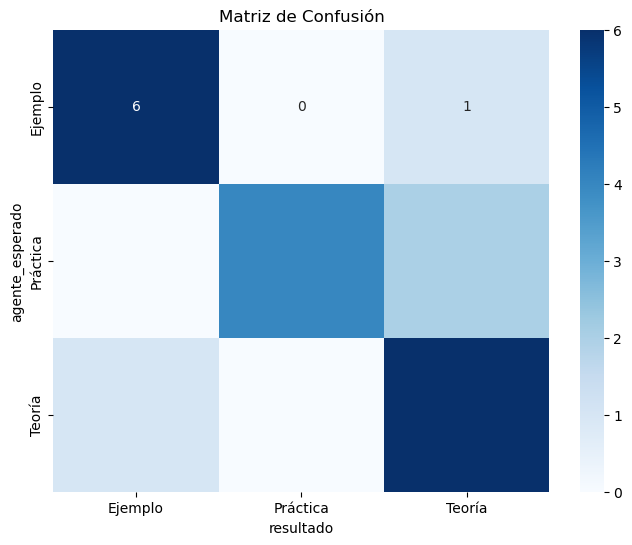

In [39]:
# 1. Mapa de calor de matriz de confusión
pd.crosstab(df['agente_esperado'], df['resultado'], margins=True)
plt.figure(figsize=(8,6))
sns.heatmap(pd.crosstab(df['agente_esperado'], df['resultado']), 
            annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')